# Midterm: WC's portion
### Mapping housing vintage / Group: Coast Live Oaks

##### Research Question: What is the relationship between coast live oak presence and neighborhood characteristics in LA County? My focus: housing vintage. 
##### Data Sources: ACS 5-year 2022, Tiger/Line 2022, iNaturalist

First I import all the libraries I will use. 

In [1]:
# for wrangling data and geospatial data
import pandas as pd
import geopandas as gpd

# for interactive charts and maps
import plotly.express as px
import folium

# for improving visuals
import matplotlib.pyplot as plt
from matplotlib import colormaps

# for adding basemaps
import contextily as ctx

I define my dataframes and read my files. 

In [2]:
# define dataframes

# read csv of ACS data on housing characteristics
df = pd.read_csv('/home/jovyan/coastliveoak/Group Data/housingData-ACS2022.csv')

# read Tiger/Line shapefile
tracts = gpd.read_file('/home/jovyan/coastliveoak/Group Data/tigerLine-tracts-2022.zip')

# read iNaturalist csv
oaks = pd.read_csv('/home/jovyan/coastliveoak/Group Data/coastliveoaksobservations.csv')

I inspect the ACS data. 

In [3]:
df.FIPS.head()

0    6037101110
1    6037101122
2    6037101220
3    6037101221
4    6037101222
Name: FIPS, dtype: int64

I solve the leading-zero problem with a function. 

In [4]:
# with arguments, function can be applied to other columns
def add_leading_zero(column, items):
    df[column] = df[column].astype(str).str.zfill(items) # convert column to string and use zfill to add leading zero

add_leading_zero('FIPS', 11)

I check to see that the zeros were added. 

In [5]:
df.FIPS.head()

0    06037101110
1    06037101122
2    06037101220
3    06037101221
4    06037101222
Name: FIPS, dtype: object

Now it's time to subset my data. The first subset will contain housing vintage. 

In [6]:
# create list
columns_vintage = [
                        'FIPS',
                        'DP04_0016E',
                        'DP04_0017E',
                    	'DP04_0018E',
                        'DP04_0019E',
                        'DP04_0020E',
                    	'DP04_0021E',
                    	'DP04_0022E',
                        'DP04_0023E',
                        'DP04_0024E',
                        'DP04_0025E',
                        'DP04_0026E'
]

# define subset
df_vintage = df[columns_vintage]

In [46]:
list(df_vintage)
columns = list(df_vintage)

# rename columns
df_vintage.columns = [
                     'FIPS',
                     'Total Housing Units',
                     '2020 or Later',
                     '2010 to 2019',
                     '2000 to 2009',
                     '1990 to 1999',
                     '1980 to 1989',
                     '1970 to 1979',
                     '1960 to 1969',
                     '1950 to 1959',
                     '1940 to 1949',
                     '1939 or Earlier'
]

df_vintage.head()

,FIPS,Total Housing Units,2020 or Later,2010 to 2019,2000 to 2009,1990 to 1999,1980 to 1989,1970 to 1979,1960 to 1969,1950 to 1959,1940 to 1949,1939 or Earlier
0,06037101110,1652,0,39,48,87,79,119,213,516,223,328
1,06037101122,1427,0,5,247,35,68,176,469,286,31,110
2,06037101220,1372,9,32,58,81,72,231,187,232,306,164
3,06037101221,1549,0,35,113,353,191,300,221,83,78,175
4,06037101222,1006,0,35,0,11,445,138,98,162,45,72


The second subset contains heating-fuel types. 

In [8]:
# create list
fuel_columns = [
                'FIPS',
                'DP04_0063E',
                'DP04_0064E',
                'DP04_0065E',
                'DP04_0066E',
                'DP04_0067E',
                'DP04_0068E',
                'DP04_0069E',
                'DP04_0070E',
                'DP04_0071E']

# define subset
df_fuel = df[fuel_columns]

In [9]:
list(df_fuel)
columns = list(df_fuel)

#rename columns 
df_fuel.columns = [ 
                    'FIPS',
                    'Utility gas',
                    'Bottled, tank, or LP gas',
                    'Electricity',
                    'Fuel oil, kersone, etc.',
                    'Coal or coke',
                    'Wood',
                    'Solar energy',
                    'Other',
                    'No fuel used']

df_fuel.head()

,FIPS,Utility gas,"Bottled, tank, or LP gas",Electricity,"Fuel oil, kersone, etc.",Coal or coke,Wood,Solar energy,Other,No fuel used
0,06037101110,1070,35,432,0,0,0,0,0,14
1,06037101122,1211,14,135,0,0,23,0,0,0
2,06037101220,959,48,308,0,0,0,0,0,34
3,06037101221,891,57,448,0,0,0,0,0,28
4,06037101222,361,37,490,12,0,0,7,0,21


Now I merge my two subsetted dataframes with the Tiger/Line data. 

In [10]:
tracts.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 9129 entries, 0 to 9128
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   STATEFP   9129 non-null   object  
 1   COUNTYFP  9129 non-null   object  
 2   TRACTCE   9129 non-null   object  
 3   GEOID     9129 non-null   object  
 4   NAME      9129 non-null   object  
 5   NAMELSAD  9129 non-null   object  
 6   MTFCC     9129 non-null   object  
 7   FUNCSTAT  9129 non-null   object  
 8   ALAND     9129 non-null   int64   
 9   AWATER    9129 non-null   int64   
 10  INTPTLAT  9129 non-null   object  
 11  INTPTLON  9129 non-null   object  
 12  geometry  9129 non-null   geometry
dtypes: geometry(1), int64(2), object(10)
memory usage: 927.3+ KB


In [11]:
tracts.GEOID.head()

0    06037137504
1    06037138000
2    06037139200
3    06087120901
4    06087120902
Name: GEOID, dtype: object

In [12]:
tracts = tracts[['GEOID','geometry']]
tracts.head()

,GEOID,geometry
0,06037137504,"POLYGON ((-118.58119 34.14318, -118.58099 34.1..."
1,06037138000,"POLYGON ((-118.60573 34.14585, -118.60561 34.1..."
2,06037139200,"POLYGON ((-118.53082 34.18024, -118.52952 34.1..."
3,06087120901,"POLYGON ((-122.04607 37.07105, -122.04505 37.0..."
4,06087120902,"POLYGON ((-122.02513 37.0432, -122.025 37.0432..."


In [13]:
# merge tracts_vintage with df_vintage on the FIPS column
tracts_vintage = tracts.merge(df_vintage, left_on='GEOID', right_on='FIPS')

# merge tracts_vintage with df_vintage on the FIPS column
tracts_fuel = tracts.merge(df_fuel, left_on="GEOID", right_on='FIPS')

# view vintage dataframe to check that merge is complete
tracts_vintage.head(1)

,GEOID,geometry,FIPS,Total Housing Units,2020 or Later,2010 to 2019,2000 to 2009,1990 to 1999,1980 to 1989,1970 to 1979,1960 to 1969,1950 to 1959,1940 to 1949,1939 or Earlier
0,06037137504,"POLYGON ((-118.58119 34.14318, -118.58099 34.1...",06037137504,702,0,0,3,7,24,251,214,151,20,32


In [14]:
# view fuel dataframe to check that merge is complete
tracts_fuel.head(1)

,GEOID,geometry,FIPS,Utility gas,"Bottled, tank, or LP gas",Electricity,"Fuel oil, kersone, etc.",Coal or coke,Wood,Solar energy,Other,No fuel used
0,06037137504,"POLYGON ((-118.58119 34.14318, -118.58099 34.1...",06037137504,581,5,60,0,0,0,8,0,8


In [15]:
tracts_fuel.crs

<Geographic 2D CRS: EPSG:4269>
Name: NAD83
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: North America - onshore and offshore: Canada - Alberta; British Columbia; Manitoba; New Brunswick; Newfoundland and Labrador; Northwest Territories; Nova Scotia; Nunavut; Ontario; Prince Edward Island; Quebec; Saskatchewan; Yukon. Puerto Rico. United States (USA) - Alabama; Alaska; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Hawaii; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming. US Virgin Islands. British Virgin Islands

For the rest of this notebook I will be working only with the vintage dataframe. I will save the fuel dataframe for the rest of the quarter. 

I want to create buckets of housing vintage that roughly correspond with "old" and "new." Old neighborhoods will be those where 50% or more of houses were built in 1959 or earlier. New neighborhoods will be those where 50% of houses were built in 2000 or later. 

In [42]:
# Create percentage columns
tracts_vintage['PCT_old'] = (tracts_vintage['1939 or Earlier'] + tracts_vintage['1940 to 1949'] + tracts_vintage['1950 to 1959']) / tracts_vintage['Total Housing Units'] * 100
tracts_vintage['PCT_new'] = (tracts_vintage['2000 to 2009'] + tracts_vintage['2010 to 2019'] + tracts_vintage['2020 or Later']) / tracts_vintage['Total Housing Units'] * 100

Now I'll create a map using one of the new columns. 

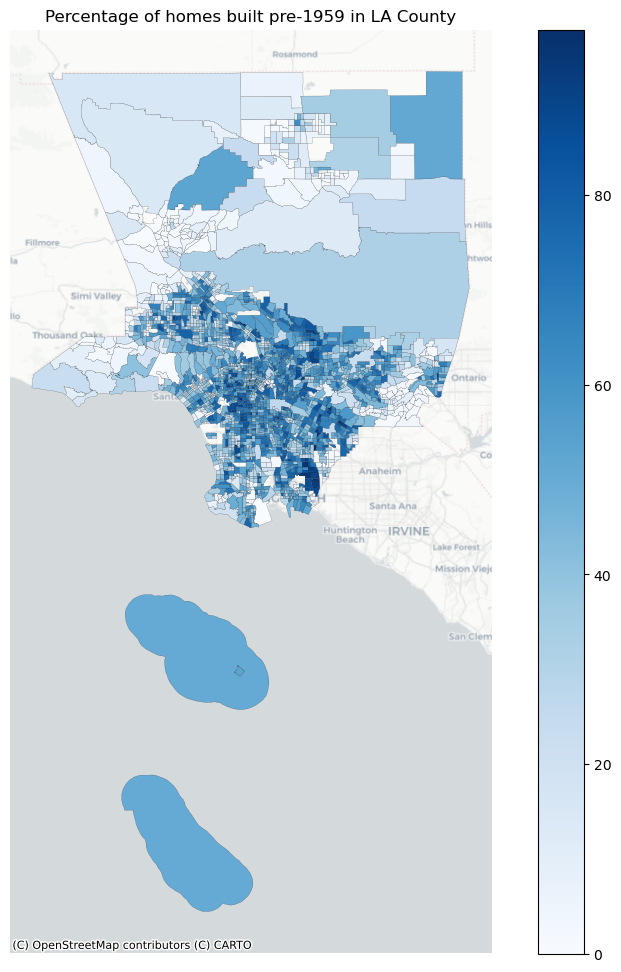

In [43]:
fig,ax = plt.subplots(figsize=(12,12))

map_vintage = tracts_vintage.plot(ax=ax, 
                         legend=True,
                         column='PCT_old',
                         cmap= 'Blues',
                         ec='black', 
                         linewidth=0.1)

ctx.add_basemap(map_vintage, crs=4269, source=ctx.providers.CartoDB.Positron) 

# turn the axes off
map_vintage.axis('off'); 

# give it a title
map_vintage.set_title('Percentage of homes built pre-1959 in LA County');

I'd like to make similar maps, so I'm going to define a function. 

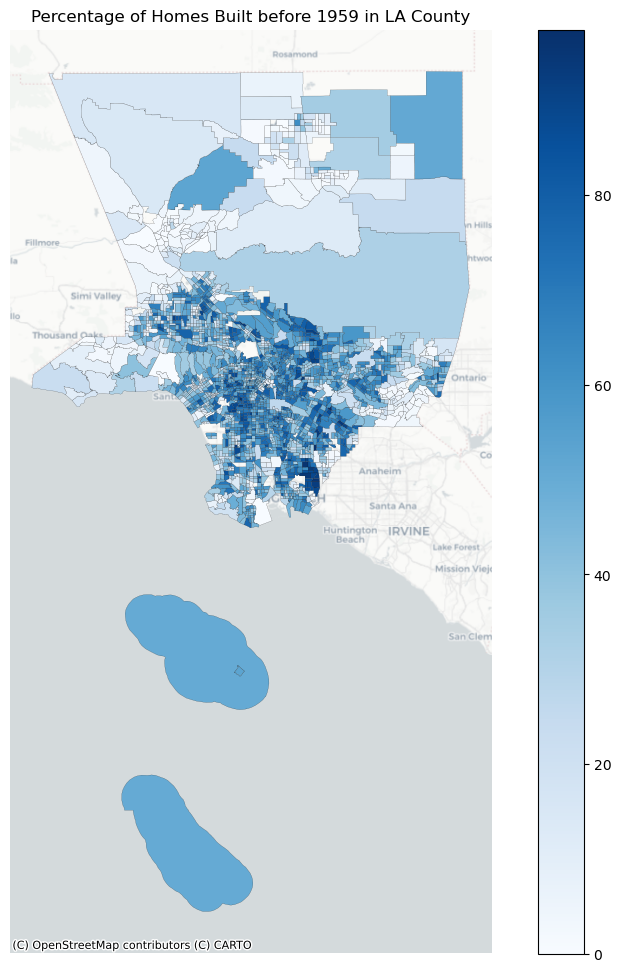

In [38]:
def housing_map(gdf, column_title, colors, title): 
    fig,ax = plt.subplots(figsize=(12,12))
    gdf.plot(ax=ax,
             legend=True,
             column=column_title,
             cmap=colors,
             ec='black', 
             linewidth=0.1)

    ctx.add_basemap(ax, crs=4269, source=ctx.providers.CartoDB.Positron) 

    ax.axis('off'); # axis off
    ax.set_title(title); # title

# call function; replicate the above map
housing_map(tracts_vintage, 'PCT_old', 'Blues', 'Percentage of Homes Built before 1959 in LA County')

# save map
plt.savefig('Completed Maps/oldHomes.jpg')

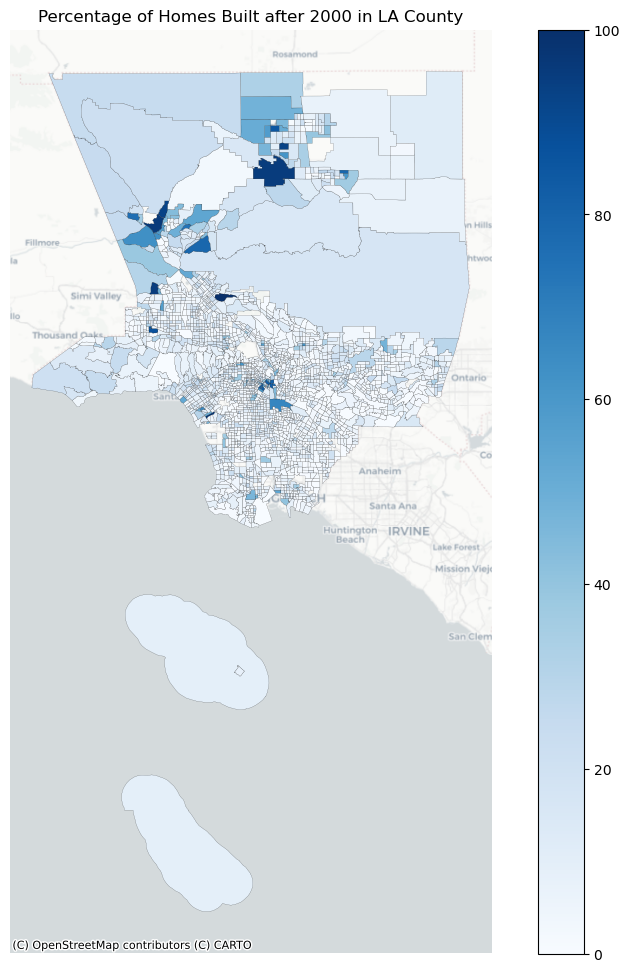

In [41]:
# create similar map, but this time for new housing units
housing_map(tracts_vintage, 'PCT_new', 'Blues', 'Percentage of Homes Built after 2000 in LA County')

# save map
plt.savefig('Completed Maps/newHomes.jpg')

Now I'm going to prepare and map the oak data. These maps won't make it into our presentation, but I'm using this space for practice and in preparation for the final. 

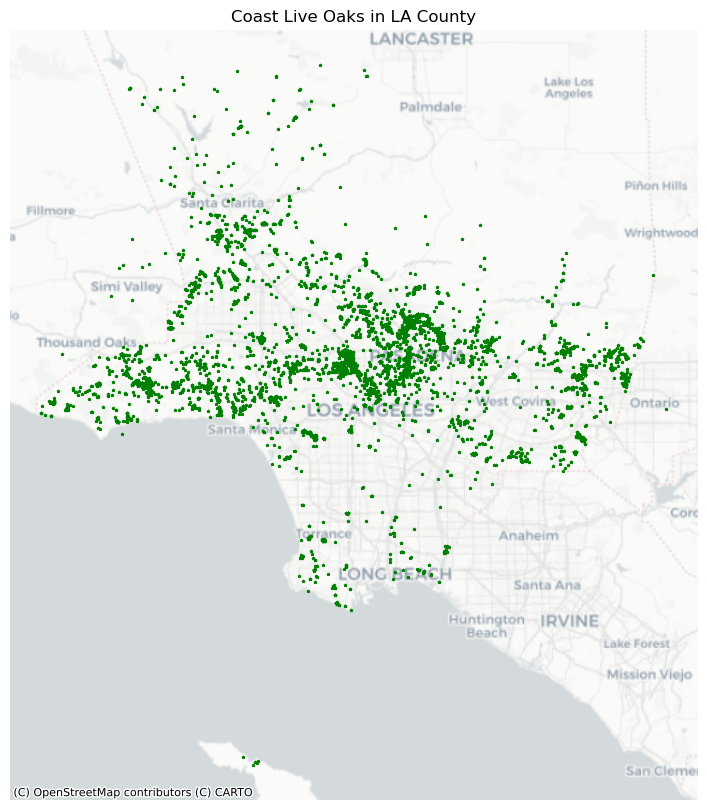

In [18]:
# convert df to gdf
# since data is in lat/lon's assign the crs to WGS84 (epsg:4326)
gdf_oaks = gpd.GeoDataFrame(oaks, 
                       geometry=gpd.points_from_xy(oaks.longitude, oaks.latitude),
                       crs='epsg:4326'
                       )

# start the plot
fig, ax = plt.subplots(figsize=(12,10)) # ax is the empty subplot

# add the data options
gdf_oaks.plot(ax=ax, 
        marker='*', # how oaks will appear on the map
        markersize=3, # font
        color='green')

# turn the axes off
ax.axis('off') 

# give it a title
ax.set_title('Coast Live Oaks in LA County')

# add a basemap
ctx.add_basemap(ax, crs=4326, source=ctx.providers.CartoDB.Positron) 

In [19]:
oaks.head()

,observed_on,updated_at,num_identification_agreements,place_guess,latitude,longitude,positional_accuracy,public_positional_accuracy,scientific_name,common_name
0,1/29/2012,2021-01-20 01:40:48 UTC,1,"34.03779220581055, -118.750244140625",34.037792,-118.750244,5.0,5.0,Quercus agrifolia,coast live oak
1,3/6/2012,2015-07-01 01:06:17 UTC,3,Central Hahamongna Park,34.193470,-118.175340,NaN,NaN,Quercus agrifolia,coast live oak
2,3/22/2012,2015-07-01 01:16:52 UTC,3,Eaton Canyon,34.193066,-118.104315,NaN,NaN,Quercus agrifolia,coast live oak
3,6/15/2012,2021-01-20 01:40:40 UTC,1,Santa Monica Mountains,34.060028,-118.932694,55.0,55.0,Quercus agrifolia,coast live oak
4,7/4/2012,2016-05-17 20:01:59 UTC,2,Eaton Canyon park,34.184842,-118.095442,811.0,811.0,Quercus agrifolia,coast live oak


Now I build an interactive map with the vintage data. I hope to use some version of this for the final. 

In [47]:
fol_vintage = folium.Map(location=[34.2,-118.2], 
               zoom_start = 10,
               tiles='CartoDB positron', 
               attribution='CartoDB')

# plot chorpleth over the base map
folium.Choropleth(
                  geo_data=tracts_vintage, # geo data
                  data=tracts_vintage, # data          
                  key_on='feature.properties.FIPS', # key, or merge column
                  columns=['FIPS','PCT_old'], # [key, value]
                  fill_color='Purples',
                  line_weight=0.1, 
                  fill_opacity=0.8,
                  line_opacity=0.2, # line opacity (of the border)
                  name='Houses built pre-1959',
                  highlight=True).add_to(fol_vintage)    # name on the legend color bar

#folium.GeoJson(data=gdf_oaks.to_json()).add_to(fol_vintage)

folium.LayerControl(collapsed=False).add_to(fol_vintage)

fol_vintage

fol_vintage.save("vintage.html")

[View (work in progress of an) interactive map](./vintage.html)

### Division of Labor

**Will**
- Obtained Tiger/Line data and housing data
- Created housing vintage maps
- Updated project proposal
- Edited presentation slides
  
**Ethan**
- Obtained oak data
- Processed oak data
- Mapped and charted oak data
- Mapped oak and racial data
  
**Caroline**
- Obtained income data
- Mapped and charted income data
- Managed repo
- Created slide deck